# Missing Values Imputation + Normalisasi Data

---
# Bagian 1: Missing Values Imputation dengan WKNN (Manual) <a id='bagian-1'></a>

## 1.1 Apa itu WKNN Imputation?

**Weighted K-Nearest Neighbour Imputation (WKNNI)** adalah pengembangan dari metode KNNI standar.  
Perbedaan utamanya:

| Metode | Cara Kerja |
|--------|------------|
| **KNNI Standar** | Mengambil rata-rata sederhana (*mean*) atau modus dari K tetangga terdekat |
| **WKNNI** | Memberikan **bobot berbeda** kepada setiap tetangga — tetangga yang lebih dekat (lebih mirip) mendapat bobot **lebih besar** |

**Logika utama:** Tetangga yang mirip seharusnya memiliki pengaruh lebih besar terhadap nilai imputasi dibandingkan tetangga yang jauh.

---

## 1.2 Rumus WKNN

### Langkah 1 — Hitung Jarak & Kemiripan ($s_i$)

Kemiripan dihitung berdasarkan **invers jarak Euclidean kuadrat**:

$$\frac{1}{s_i} = \sum_{h_i \in O_i \cap O_j} (y_{ih} - y_{jh})^2$$

Sehingga:

$$s_i = \frac{1}{\sum_{h_i \in O_i \cap O_j} (y_{ih} - y_{jh})^2}$$

**Keterangan:**
- $y_{ih}$ : nilai atribut ke-$h$ dari data target $y_i$  
- $y_{jh}$ : nilai atribut ke-$h$ dari tetangga $y_j$  
- $O_i \cap O_j$ : himpunan atribut yang **teramati** (ada datanya) pada **kedua** objek  
- Jarak kecil → $s_i$ besar (sangat mirip)

### Langkah 2 — Hitung Estimasi (Weighted Average)

$$\hat{y}_{ih} = \frac{\sum_{j \in I_{Kih}} s_i(y_j) \cdot y_{jh}}{\sum_{j \in I_{Kih}} s_i(y_j)}$$

**Keterangan:**
- $I_{Kih}$ : himpunan K tetangga terdekat dari data ke-$i$ pada atribut ke-$h$
- Pembilang = jumlah (bobot × nilai tetangga)
- Penyebut = jumlah total bobot (normalisasi)

---
## 1.3 Contoh Manual — Data Numerik (Regresi)

**Dataset:** Data harga sewa properti

| ID | Luas ($x$) m² | Harga Sewa ($y$) Juta |
|----|---------------|------------------------|
| $y_1$ | 20 | 2.0 |
| $y_2$ | 25 | 2.4 |
| $y_3$ | 35 | 3.5 |
| $y_4$ | 40 | 4.2 |
| $y_5$ | 50 | 5.1 |
| $y_6$ | 60 | 6.5 |
| **$y_7$** | **30** | **? (Hilang)** |

**Data Target ($y_7$):** Luas = 30 m², Harga Sewa = **?**

---

### Langkah 1: Hitung Kemiripan $s_i$

Karena hanya ada 1 fitur teramati (Luas), rumusnya menjadi:
$$\frac{1}{s_i} = (x_i - x_j)^2$$

| Tetangga | Selisih ($x_i - x_j$) | Kuadrat ($1/s_i$) | Kemiripan ($s_i$) |
|----------|------------------------|-------------------|--------------------|
| $y_1$    | $30 - 20 = 10$         | 100               | $1/100 = 0.0100$   |
| $y_2$    | $30 - 25 = 5$          | 25                | $1/25 = 0.0400$    |
| $y_3$    | $30 - 35 = -5$         | 25                | $1/25 = 0.0400$    |
| $y_4$    | $30 - 40 = -10$        | 100               | $1/100 = 0.0100$   |
| $y_5$    | $30 - 50 = -20$        | 400               | $1/400 = 0.0025$   |
| $y_6$    | $30 - 60 = -30$        | 900               | $1/900 = 0.0011$   |

### Langkah 2: Hitung Weighted Average

**A. Pembilang** $\sum s_i \cdot y_j$:

| Tetangga | $s_i$ | $y_j$ | $s_i \times y_j$ |
|----------|--------|--------|-------------------|
| $y_1$ | 0.0100 | 2.0 | 0.0200 |
| $y_2$ | 0.0400 | 2.4 | 0.0960 |
| $y_3$ | 0.0400 | 3.5 | 0.1400 |
| $y_4$ | 0.0100 | 4.2 | 0.0420 |
| $y_5$ | 0.0025 | 5.1 | 0.01275 |
| $y_6$ | 0.0011 | 6.5 | 0.00715 |
| **Total** | | | **0.3179** |

**B. Penyebut** $\sum s_i$:
$$0.0100 + 0.0400 + 0.0400 + 0.0100 + 0.0025 + 0.0011 = 0.1036$$

###  Hasil Akhir
$$\hat{y}_7 = \frac{0.3179}{0.1036} \approx \mathbf{3.07 \text{ Juta}}$$

>  **Interpretasi:** Data $y_3$ (Luas=35) dan $y_2$ (Luas=25) mendapat bobot terbesar karena paling dekat dengan Luas=30, sehingga nilai estimasi harga sewa lebih dipengaruhi oleh kedua data tersebut.

---
## 1.4 Contoh Manual — Data Klasifikasi (Same-Class Weighting)

**Dataset:** Data pelamar kerja

| ID | Pengalaman ($x_1$) thn | Skor Tes ($x_2$) | Kelas |
|----|------------------------|------------------|-------|
| $y_1$ | 2 | 70 | 0 (Gagal) |
| $y_2$ | 3 | 75 | 0 (Gagal) |
| $y_3$ | 5 | 85 | 1 (Lulus) |
| $y_4$ | 6 | 88 | 1 (Lulus) |
| $y_5$ | 1 | 65 | 0 (Gagal) |
| $y_6$ | 7 | 92 | 1 (Lulus) |
| **$y_7$** | **5.5** | **? (Hilang)** | **1 (Lulus)** |

**Strategi:** Gunakan hanya tetangga dengan **kelas yang sama** (Kelas 1) karena fiturnya lebih relevan.

---

### Langkah 1: Hitung Kemiripan (semua tetangga)

| Tetangga | Selisih ($5.5 - x_{j1}$) | Kuadrat ($1/s_i$) | $s_i$ | Kelas |
|----------|--------------------------|-------------------|--------|-------|
| $y_1$ | $5.5 - 2 = 3.5$  | 12.25 | 0.081 | 0 |
| $y_2$ | $5.5 - 3 = 2.5$  | 6.25  | 0.160 | 0 |
| $y_3$ | $5.5 - 5 = 0.5$  | 0.25  | **4.000** | **1** |
| $y_4$ | $5.5 - 6 = -0.5$ | 0.25  | **4.000** | **1** |
| $y_5$ | $5.5 - 1 = 4.5$  | 20.25 | 0.049 | 0 |
| $y_6$ | $5.5 - 7 = -1.5$ | 2.25  | **0.444** | **1** |

### Langkah 2 & 3: Filter Kelas 1 + Hitung Estimasi

**A. Pembilang** $\sum s_i \cdot \text{Skor}_j$ (hanya Kelas 1):

| Tetangga | $s_i$ | Skor Tes | $s_i \times \text{Skor}$ |
|----------|--------|----------|---------------------------|
| $y_3$ | 4.000 | 85 | 340.000 |
| $y_4$ | 4.000 | 88 | 352.000 |
| $y_6$ | 0.444 | 92 | 40.848 |
| **Total** | **8.444** | | **732.848** |

###  Hasil Akhir
$$\hat{y}_7 = \frac{732.848}{8.444} \approx \mathbf{86.79}$$

>  **Interpretasi:** Karena data target berkelas 1 (Lulus), estimasi skor hanya menggunakan sesama pelamar yang lulus. Hasilnya (86.79) berada di antara skor $y_3$ (85) dan $y_4$ (88) karena jarak ke keduanya sama.

---
# Bagian 2: Implementasi WKNN dengan Code Python <a id='bagian-2'></a>

In [12]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimpor!")

Library berhasil diimpor!


## 2.1 Implementasi WKNN Manual — Contoh 1 (Data Numerik)

In [13]:
# ============================================================
#  Contoh 1: WKNN untuk Data Numerik (Harga Sewa Properti)
# ============================================================

# Dataset: kolom 0 = Luas (x), kolom 1 = Harga Sewa (y)
data = np.array([
    [20, 2.0],   # y1
    [25, 2.4],   # y2
    [35, 3.5],   # y3
    [40, 4.2],   # y4
    [50, 5.1],   # y5
    [60, 6.5],   # y6
])

# Data target: Luas = 30, Harga Sewa = NaN (hilang)
target = np.array([30, np.nan])

# Indeks atribut yang hilang
missing_col = 1   # kolom Harga Sewa
observed_col = 0  # kolom Luas (digunakan untuk menghitung jarak)

print("="*55)
print(" WKNN IMPUTATION — CONTOH 1: DATA NUMERIK")
print("="*55)
print(f"\nData Target → Luas: {target[observed_col]} m², Harga Sewa: ?")
print("\n--- Dataset ---")
df = pd.DataFrame(data, columns=["Luas (m²)", "Harga Sewa (Juta)"],
                  index=[f"y{i+1}" for i in range(len(data))])
print(df.to_string())

 WKNN IMPUTATION — CONTOH 1: DATA NUMERIK

Data Target → Luas: 30.0 m², Harga Sewa: ?

--- Dataset ---
    Luas (m²)  Harga Sewa (Juta)
y1       20.0                2.0
y2       25.0                2.4
y3       35.0                3.5
y4       40.0                4.2
y5       50.0                5.1
y6       60.0                6.5


In [14]:
# ─────────────────────────────────────────────────────────────
#  LANGKAH 1: Hitung Jarak Euclidean Kuadrat & Kemiripan (s_i)
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*55)
print(" LANGKAH 1: Hitung Kemiripan (s_i)")
print("─"*55)
print(f" Rumus: 1/s_i = (x_target - x_tetangga)²")
print(f" Rumus: s_i   = 1 / (1/s_i)")
print("─"*55)

similarities = []
header = f"{'Tetangga':<10} {'Selisih':>10} {'1/s_i (kuadrat)':>18} {'s_i (kemiripan)':>18}"
print(header)
print("-" * len(header))

for i, row in enumerate(data):
    selisih = target[observed_col] - row[observed_col]
    inv_sim = selisih ** 2                  # 1/s_i
    
    if inv_sim == 0:
        # Jarak = 0 → data identik → kemiripan tak terhingga
        sim = float('inf')
    else:
        sim = 1 / inv_sim                   # s_i
    
    similarities.append(sim)
    print(f"  y{i+1:<8} {selisih:>10.1f} {inv_sim:>18.4f} {sim:>18.6f}")

print("-" * len(header))
print(f"{'Total s_i':>42} {sum(similarities):>18.6f}")


───────────────────────────────────────────────────────
 LANGKAH 1: Hitung Kemiripan (s_i)
───────────────────────────────────────────────────────
 Rumus: 1/s_i = (x_target - x_tetangga)²
 Rumus: s_i   = 1 / (1/s_i)
───────────────────────────────────────────────────────
Tetangga      Selisih    1/s_i (kuadrat)    s_i (kemiripan)
-----------------------------------------------------------
  y1              10.0           100.0000           0.010000
  y2               5.0            25.0000           0.040000
  y3              -5.0            25.0000           0.040000
  y4             -10.0           100.0000           0.010000
  y5             -20.0           400.0000           0.002500
  y6             -30.0           900.0000           0.001111
-----------------------------------------------------------
                                 Total s_i           0.103611


In [15]:
# ─────────────────────────────────────────────────────────────
#  LANGKAH 2: Hitung Weighted Average (Estimasi Nilai Hilang)
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*55)
print(" LANGKAH 2: Hitung Weighted Average")
print("─"*55)
print(" Rumus: ŷ = Σ(s_i × y_j) / Σ(s_i)")
print("─"*55)

pembilang_total = 0
penyebut_total  = 0

header2 = f"{'Tetangga':<10} {'s_i':>10} {'y_j (Harga)':>14} {'s_i × y_j':>14}"
print(header2)
print("-" * len(header2))

for i, (row, sim) in enumerate(zip(data, similarities)):
    nilai_tetangga = row[missing_col]
    kontribusi = sim * nilai_tetangga
    pembilang_total += kontribusi
    penyebut_total  += sim
    print(f"  y{i+1:<8} {sim:>10.6f} {nilai_tetangga:>14.1f} {kontribusi:>14.6f}")

print("-" * len(header2))
print(f"{'Total':>24} {penyebut_total:>14.6f} {pembilang_total:>14.6f}")

estimasi = pembilang_total / penyebut_total

print("\n" + "="*55)
print(f" HASIL ESTIMASI WKNN:")
print(f"   ŷ₇ = {pembilang_total:.4f} / {penyebut_total:.4f}")
print(f"   ŷ₇ = {estimasi:.4f} Juta ≈ Rp {estimasi*1e6:,.0f}")
print("="*55)


───────────────────────────────────────────────────────
 LANGKAH 2: Hitung Weighted Average
───────────────────────────────────────────────────────
 Rumus: ŷ = Σ(s_i × y_j) / Σ(s_i)
───────────────────────────────────────────────────────
Tetangga          s_i    y_j (Harga)      s_i × y_j
---------------------------------------------------
  y1          0.010000            2.0       0.020000
  y2          0.040000            2.4       0.096000
  y3          0.040000            3.5       0.140000
  y4          0.010000            4.2       0.042000
  y5          0.002500            5.1       0.012750
  y6          0.001111            6.5       0.007222
---------------------------------------------------
                   Total       0.103611       0.317972

 HASIL ESTIMASI WKNN:
   ŷ₇ = 0.3180 / 0.1036
   ŷ₇ = 3.0689 Juta ≈ Rp 3,068,901


## 2.2 Fungsi WKNN Generik

In [16]:
def hitung_kemiripan_wknn(target_row, data, observed_cols):
    """
    Menghitung kemiripan s_i antara data target dan semua tetangga.
    
    Parameters
    ----------
    target_row    : array, baris data target (bisa mengandung NaN)
    data          : array 2D, dataset tanpa missing values
    observed_cols : list of int, indeks kolom yang teramati pada target
    
    Returns
    -------
    similarities  : array, nilai kemiripan s_i untuk setiap tetangga
    """
    similarities = []
    for row in data:
        inv_sim = sum(
            (target_row[h] - row[h]) ** 2
            for h in observed_cols
        )
        sim = 1 / inv_sim if inv_sim != 0 else float('inf')
        similarities.append(sim)
    return np.array(similarities)


def wknn_impute(target_row, data, missing_col, k=None,
                class_col=None, target_class=None):
    """
    WKNN Imputation untuk satu nilai yang hilang.
    
    Parameters
    ----------
    target_row   : array, baris data target
    data         : array 2D, dataset referensi (tanpa missing)
    missing_col  : int, indeks kolom yang hilang
    k            : int or None. Jika None → gunakan semua tetangga
    class_col    : int or None. Indeks kolom kelas (untuk klasifikasi)
    target_class : skalar. Kelas dari data target (untuk same-class weighting)
    
    Returns
    -------
    estimasi : float, nilai imputasi
    """
    n_cols = data.shape[1]
    
    # Tentukan kolom yang teramati (bukan kolom yang hilang, bukan kolom kelas)
    exclude = {missing_col}
    if class_col is not None:
        exclude.add(class_col)
    observed_cols = [h for h in range(n_cols) if h not in exclude]
    
    # Filter berdasarkan kelas jika diminta
    kandidat = data.copy()
    if class_col is not None and target_class is not None:
        mask = kandidat[:, class_col] == target_class
        kandidat = kandidat[mask]
    
    # Hitung kemiripan
    sims = hitung_kemiripan_wknn(target_row, kandidat, observed_cols)
    
    # Pilih K tetangga terdekat (terbesar s_i)
    if k is not None and k < len(sims):
        top_k_idx = np.argsort(sims)[::-1][:k]
        kandidat  = kandidat[top_k_idx]
        sims      = sims[top_k_idx]
    
    # Weighted Average
    pembilang = np.sum(sims * kandidat[:, missing_col])
    penyebut  = np.sum(sims)
    
    return pembilang / penyebut


print("Fungsi wknn_impute() berhasil didefinisikan!")

Fungsi wknn_impute() berhasil didefinisikan!


In [17]:
# ─────────────────────────────────────────────────────────────
#  Verifikasi Contoh 1 menggunakan fungsi generik
# ─────────────────────────────────────────────────────────────

data_ex1   = np.array([[20,2.0],[25,2.4],[35,3.5],[40,4.2],[50,5.1],[60,6.5]])
target_ex1 = np.array([30, np.nan])

hasil_ex1 = wknn_impute(target_ex1, data_ex1, missing_col=1)
print(f"Contoh 1 — Estimasi Harga Sewa: {hasil_ex1:.4f} Juta")
print(f"  (Manual: 3.068 Juta →  Konsisten)")

Contoh 1 — Estimasi Harga Sewa: 3.0689 Juta
  (Manual: 3.068 Juta →  Konsisten)


In [18]:
# ─────────────────────────────────────────────────────────────
#  Verifikasi Contoh 2 — Data Klasifikasi (Same-Class Weighting)
# ─────────────────────────────────────────────────────────────

print("="*55)
print(" CONTOH 2: WKNN — DATA KLASIFIKASI")
print(" (Same-Class Weighting)")
print("="*55)

# Kolom: [Pengalaman(x1), Skor Tes(x2), Kelas]
data_ex2 = np.array([
    [2, 70, 0],   # y1 - Gagal
    [3, 75, 0],   # y2 - Gagal
    [5, 85, 1],   # y3 - Lulus
    [6, 88, 1],   # y4 - Lulus
    [1, 65, 0],   # y5 - Gagal
    [7, 92, 1],   # y6 - Lulus
], dtype=float)

# Target: Pengalaman=5.5, Skor Tes=NaN, Kelas=1
target_ex2   = np.array([5.5, np.nan, 1.0])
target_class = 1

hasil_ex2 = wknn_impute(
    target_ex2, data_ex2,
    missing_col=1,
    class_col=2,
    target_class=target_class
)

print(f"\nEstimasi Skor Tes (hanya Kelas 1): {hasil_ex2:.4f}")
print(f"  (Manual: 86.79 →  Konsisten)")

 CONTOH 2: WKNN — DATA KLASIFIKASI
 (Same-Class Weighting)

Estimasi Skor Tes (hanya Kelas 1): 86.7895
  (Manual: 86.79 →  Konsisten)


## 2.3 Implementasi WKNN pada DataFrame dengan Multiple Missing Values

In [19]:
# ─────────────────────────────────────────────────────────────
#  Dataset baru dengan beberapa nilai hilang
# ─────────────────────────────────────────────────────────────

df_raw = pd.DataFrame({
    'Usia':       [22, 25, np.nan, 30, 35, 28, np.nan, 40],
    'Pendapatan': [3.5, 4.0, 5.2, np.nan, 7.0, 4.8, 6.1, np.nan],
    'Pengeluaran':[2.0, 2.5, 3.0, 4.5, 5.5, 3.5, 4.0, 6.0],
})

print("Dataset dengan Missing Values:")
print(df_raw.to_string())
print(f"\nJumlah missing per kolom:")
print(df_raw.isnull().sum())

Dataset dengan Missing Values:
   Usia  Pendapatan  Pengeluaran
0  22.0         3.5          2.0
1  25.0         4.0          2.5
2   NaN         5.2          3.0
3  30.0         NaN          4.5
4  35.0         7.0          5.5
5  28.0         4.8          3.5
6   NaN         6.1          4.0
7  40.0         NaN          6.0

Jumlah missing per kolom:
Usia           2
Pendapatan     2
Pengeluaran    0
dtype: int64


In [21]:
def wknn_impute_dataframe(df, k=3):
    """
    WKNN Imputation untuk seluruh DataFrame.
    Menangani multiple missing values per baris.
    
    Parameters
    ----------
    df : pd.DataFrame, dataset dengan NaN
    k  : int, jumlah tetangga
    
    Returns
    -------
    df_imputed : pd.DataFrame, dataset setelah imputasi
    """
    df_imputed = df.copy()
    data_arr   = df.values.astype(float)
    n_rows, n_cols = data_arr.shape
    
    for row_idx in range(n_rows):
        row = data_arr[row_idx]
        missing_cols  = np.where(np.isnan(row))[0]
        observed_cols = np.where(~np.isnan(row))[0]
        
        if len(missing_cols) == 0:
            continue  # tidak ada nilai hilang
        
        # Kandidat tetangga: baris yang tidak mengandung NaN pada observed_cols
        complete_mask = ~np.any(np.isnan(data_arr[:, observed_cols]), axis=1)
        complete_mask[row_idx] = False  # Hapus diri sendiri
        kandidat = data_arr[complete_mask]
        
        if len(kandidat) == 0:
            print(f"   Baris {row_idx}: tidak cukup tetangga lengkap!")
            continue
        
        # Hitung kemiripan berdasarkan atribut yang teramati
        sims = hitung_kemiripan_wknn(row, kandidat, observed_cols.tolist())
        
        # Ambil K tetangga terbaik
        k_actual  = min(k, len(sims))
        top_k_idx = np.argsort(sims)[::-1][:k_actual]
        top_data  = kandidat[top_k_idx]
        top_sims  = sims[top_k_idx]
        
        # Imputasi tiap kolom yang hilang
        for mc in missing_cols:
            valid = ~np.isnan(top_data[:, mc])
            if valid.sum() == 0:
                print(f"  Baris {row_idx}, kolom {mc}: tetangga tidak punya nilai!")
                continue
            pembilang = np.sum(top_sims[valid] * top_data[valid, mc])
            penyebut  = np.sum(top_sims[valid])
            estimasi  = pembilang / penyebut
            df_imputed.iloc[row_idx, mc] = round(estimasi, 4)
    
    return df_imputed


# ─────────────────────────────────────────────────────────────
#  Jalankan imputasi
# ─────────────────────────────────────────────────────────────

df_imputed = wknn_impute_dataframe(df_raw, k=3)

print("\nHasil Setelah WKNN Imputation (K=3):")
print(df_imputed.to_string())

print("\nPerbandingan sebelum & sesudah:")
comparison = df_raw.copy().astype(object)
for col in df_raw.columns:
    mask = df_raw[col].isna()
    if mask.any():
        comparison.loc[mask, col] = df_imputed.loc[mask, col].apply(
            lambda v: f"→ {v:.4f} (diimputasi)"
        )
print(comparison.to_string())


Hasil Setelah WKNN Imputation (K=3):
      Usia  Pendapatan  Pengeluaran
0  22.0000      3.5000          2.0
1  25.0000      4.0000          2.5
2  27.4143      5.2000          3.0
3  30.0000      5.0089          4.5
4  35.0000      7.0000          5.5
5  28.0000      4.8000          3.5
6  30.7160      6.1000          4.0
7  40.0000      6.6835          6.0

Perbandingan sebelum & sesudah:
                     Usia             Pendapatan Pengeluaran
0                    22.0                    3.5         2.0
1                    25.0                    4.0         2.5
2  → 27.4143 (diimputasi)                    5.2         3.0
3                    30.0  → 5.0089 (diimputasi)         4.5
4                    35.0                    7.0         5.5
5                    28.0                    4.8         3.5
6  → 30.7160 (diimputasi)                    6.1         4.0
7                    40.0  → 6.6835 (diimputasi)         6.0


---
# Bagian 3: Normalisasi Data (Materi) <a id='bagian-3'></a>

## 3.1 Pengertian Normalisasi

**Normalisasi data** adalah proses mengubah skala nilai fitur ke dalam rentang tertentu atau distribusi tertentu, sehingga tidak ada fitur yang mendominasi proses pembelajaran hanya karena skalanya lebih besar.

**Mengapa penting?**
- Algoritma berbasis jarak (KNN, K-Means) sangat sensitif terhadap skala fitur
- Gradient descent lebih cepat konvergen
- Membuat koefisien model lebih mudah dibandingkan

---

## 3.2 Macam-macam Normalisasi Data

### A. Min-Max Normalization (Rescaling)

**Rumus:**
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**Dengan rentang target $[a, b]$:**
$$x' = a + \frac{(x - x_{\min})(b - a)}{x_{\max} - x_{\min}}$$

- Mengubah nilai ke rentang **[0, 1]** (default)
- **Kelebihan:** Sederhana, rentang terkontrol
- **Kekurangan:** Sangat sensitif terhadap outlier
- **Cocok untuk:** Neural network, image pixel, algoritma berbasis jarak

---

### B. Z-Score Standardization (Standard Scaler)

**Rumus:**
$$x' = \frac{x - \mu}{\sigma}$$

- $\mu$ = mean, $\sigma$ = standard deviation
- Mengubah data menjadi distribusi dengan **mean=0, std=1**
- **Kelebihan:** Tidak sensitif terhadap outlier, cocok untuk distribusi Gaussian
- **Kekurangan:** Tidak menjamin rentang tetap
- **Cocok untuk:** SVM, Logistic Regression, PCA

---

### C. Robust Scaler

**Rumus:**
$$x' = \frac{x - Q_2}{Q_3 - Q_1}$$

- $Q_2$ = median, $Q_1$ = kuartil 1, $Q_3$ = kuartil 3
- Menggunakan statistik yang **tahan outlier** (median dan IQR)
- **Kelebihan:** Sangat robust terhadap outlier
- **Kekurangan:** Nilai hasil tidak terbatas pada rentang tertentu
- **Cocok untuk:** Data dengan banyak outlier

---

### D. Decimal Scaling

**Rumus:**
$$x' = \frac{x}{10^d}$$

- $d$ = nilai terkecil dimana $\max(|x'|) < 1$
- Menggeser tanda desimal
- **Kelebihan:** Sangat sederhana
- **Kekurangan:** Bergantung pada nilai maksimum data

---

### E. L1 / L2 Normalization (Normalizer)

**L1 Norm:**
$$x' = \frac{x}{\sum |x_i|}$$

**L2 Norm:**
$$x' = \frac{x}{\sqrt{\sum x_i^2}}$$

- Normalisasi per **baris** (bukan per kolom)
- Setiap vektor menjadi unit vector
- **Cocok untuk:** Text data, sparse features, cosine similarity

---

### F. MAD Z-Score (Robust Z-Score)

**Rumus:**
$$x' = \frac{x - \mu}{s_{mad}}$$

di mana: $s_{mad} = \frac{1}{n}\sum_{i=1}^{n}|x_i - \bar{x}|$ (Mean Absolute Deviation)

- Lebih **robust** dari Z-score standar karena MAD tidak dipengaruhi nilai ekstrem seperti variance
- Dibahas dalam materi **Mengukur Jarak (Standarisasi Numerik)**

---

### Rangkuman Perbandingan

| Metode | Rentang Hasil | Tahan Outlier | Sklearn Class |
|--------|---------------|---------------|---------------|
| Min-Max | [0, 1] | Tidak | `MinMaxScaler` |
| Z-Score | ~[-3, 3] | Cukup | `StandardScaler` |
| Robust Scaler | Tidak tetap | Ya | `RobustScaler` |
| Decimal Scaling | (-1, 1) | Cukup | Manual |
| L1/L2 Norm | Per baris |  - | `Normalizer` |
| MAD Z-Score | ~[-3, 3] | Ya | Manual |

---
# Bagian 4: Implementasi Normalisasi <a id='bagian-4'></a>

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler, Normalizer
)

# ─────────────────────────────────────────────────────────────
#  Dataset contoh untuk normalisasi
# ─────────────────────────────────────────────────────────────

data_norm = {
    'Usia':       [22, 25, 30, 35, 40, 28, 55, 19],
    'Pendapatan': [3_500_000, 4_000_000, 5_200_000, 7_000_000,
                   9_000_000, 4_800_000, 15_000_000, 2_500_000],
    'Pengeluaran':[2_000_000, 2_500_000, 3_000_000, 4_500_000,
                   6_000_000, 3_500_000, 12_000_000, 1_500_000],
}

df_norm = pd.DataFrame(data_norm)

print("Dataset Original:")
print(df_norm.to_string())
print("\nStatistik Deskriptif:")
print(df_norm.describe().round(2).to_string())

Dataset Original:
   Usia  Pendapatan  Pengeluaran
0    22     3500000      2000000
1    25     4000000      2500000
2    30     5200000      3000000
3    35     7000000      4500000
4    40     9000000      6000000
5    28     4800000      3500000
6    55    15000000     12000000
7    19     2500000      1500000

Statistik Deskriptif:
        Usia   Pendapatan  Pengeluaran
count   8.00         8.00         8.00
mean   31.75   6375000.00   4375000.00
std    11.59   4043601.65   3399054.49
min    19.00   2500000.00   1500000.00
25%    24.25   3875000.00   2375000.00
50%    29.00   5000000.00   3250000.00
75%    36.25   7500000.00   4875000.00
max    55.00  15000000.00  12000000.00


## 4.1 Min-Max Normalization

In [24]:
# ─── A. Menggunakan sklearn ───────────────────────────────────
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
df_minmax_sklearn = pd.DataFrame(
    scaler_minmax.fit_transform(df_norm),
    columns=df_norm.columns
).round(4)

print("=" * 60)
print(" MIN-MAX NORMALIZATION (sklearn MinMaxScaler)")
print("=" * 60)
print(df_minmax_sklearn.to_string())

# ─── B. Fungsi Manual ─────────────────────────────────────────
def minmax_manual(X):
    """Min-Max normalization ke [0,1] secara manual."""
    X = np.array(X, dtype=float)
    x_min = X.min(axis=0)
    x_max = X.max(axis=0)
    return (X - x_min) / (x_max - x_min)

df_minmax_manual = pd.DataFrame(
    minmax_manual(df_norm.values),
    columns=df_norm.columns
).round(4)

print("\nMin-Max Normalization (Fungsi Manual):")
print(df_minmax_manual.to_string())

# Verifikasi kesamaan
assert np.allclose(df_minmax_sklearn.values, df_minmax_manual.values)
print("\n Hasil sklearn dan manual IDENTIK!")
print(f"   Nilai min hasil: {df_minmax_sklearn.min().min():.1f}")
print(f"   Nilai max hasil: {df_minmax_sklearn.max().max():.1f}")

 MIN-MAX NORMALIZATION (sklearn MinMaxScaler)
     Usia  Pendapatan  Pengeluaran
0  0.0833       0.080       0.0476
1  0.1667       0.120       0.0952
2  0.3056       0.216       0.1429
3  0.4444       0.360       0.2857
4  0.5833       0.520       0.4286
5  0.2500       0.184       0.1905
6  1.0000       1.000       1.0000
7  0.0000       0.000       0.0000

Min-Max Normalization (Fungsi Manual):
     Usia  Pendapatan  Pengeluaran
0  0.0833       0.080       0.0476
1  0.1667       0.120       0.0952
2  0.3056       0.216       0.1429
3  0.4444       0.360       0.2857
4  0.5833       0.520       0.4286
5  0.2500       0.184       0.1905
6  1.0000       1.000       1.0000
7  0.0000       0.000       0.0000

 Hasil sklearn dan manual IDENTIK!
   Nilai min hasil: 0.0
   Nilai max hasil: 1.0


## 4.2 Z-Score Standardization

In [25]:
# ─── A. Menggunakan sklearn ───────────────────────────────────
scaler_std = StandardScaler()
df_zscore_sklearn = pd.DataFrame(
    scaler_std.fit_transform(df_norm),
    columns=df_norm.columns
).round(4)

print("=" * 60)
print(" Z-SCORE STANDARDIZATION (sklearn StandardScaler)")
print("=" * 60)
print(df_zscore_sklearn.to_string())

# ─── B. Fungsi Manual ─────────────────────────────────────────
def zscore_manual(X):
    """Z-Score standardization: (x - mean) / std"""
    X    = np.array(X, dtype=float)
    mean = X.mean(axis=0)
    std  = X.std(axis=0)   # ddof=0 (population std) ← sama dengan sklearn
    return (X - mean) / std

df_zscore_manual = pd.DataFrame(
    zscore_manual(df_norm.values),
    columns=df_norm.columns
).round(4)

print("\nZ-Score (Fungsi Manual):")
print(df_zscore_manual.to_string())

assert np.allclose(df_zscore_sklearn.values, df_zscore_manual.values)
print("\n Hasil sklearn dan manual IDENTIK!")
print(f"   Mean hasil ≈ {df_zscore_sklearn.mean().mean():.6f} (mendekati 0)")
print(f"   Std  hasil ≈ {df_zscore_sklearn.std().mean():.4f} (mendekati 1)")

 Z-SCORE STANDARDIZATION (sklearn StandardScaler)
     Usia  Pendapatan  Pengeluaran
0 -0.8997     -0.7601      -0.7470
1 -0.6229     -0.6279      -0.5897
2 -0.1615     -0.3106      -0.4325
3  0.2999      0.1652       0.0393
4  0.7613      0.6940       0.5111
5 -0.3460     -0.4164      -0.2752
6  2.1455      2.2803       2.3982
7 -1.1765     -1.0245      -0.9042

Z-Score (Fungsi Manual):
     Usia  Pendapatan  Pengeluaran
0 -0.8997     -0.7601      -0.7470
1 -0.6229     -0.6279      -0.5897
2 -0.1615     -0.3106      -0.4325
3  0.2999      0.1652       0.0393
4  0.7613      0.6940       0.5111
5 -0.3460     -0.4164      -0.2752
6  2.1455      2.2803       2.3982
7 -1.1765     -1.0245      -0.9042

 Hasil sklearn dan manual IDENTIK!
   Mean hasil ≈ 0.000004 (mendekati 0)
   Std  hasil ≈ 1.0691 (mendekati 1)


## 4.3 Robust Scaler

In [26]:
# ─── A. Menggunakan sklearn ───────────────────────────────────
scaler_robust = RobustScaler()
df_robust_sklearn = pd.DataFrame(
    scaler_robust.fit_transform(df_norm),
    columns=df_norm.columns
).round(4)

print("=" * 60)
print(" ROBUST SCALER (sklearn RobustScaler)")
print("=" * 60)
print(df_robust_sklearn.to_string())

# ─── B. Fungsi Manual ─────────────────────────────────────────
def robust_scaler_manual(X):
    """Robust scaling: (x - median) / IQR"""
    X      = np.array(X, dtype=float)
    median = np.median(X, axis=0)
    q1     = np.percentile(X, 25, axis=0)
    q3     = np.percentile(X, 75, axis=0)
    iqr    = q3 - q1
    return (X - median) / iqr

df_robust_manual = pd.DataFrame(
    robust_scaler_manual(df_norm.values),
    columns=df_norm.columns
).round(4)

print("\nRobust Scaler (Fungsi Manual):")
print(df_robust_manual.to_string())

assert np.allclose(df_robust_sklearn.values, df_robust_manual.values)
print("\n Hasil sklearn dan manual IDENTIK!")

 ROBUST SCALER (sklearn RobustScaler)
     Usia  Pendapatan  Pengeluaran
0 -0.5833     -0.4138         -0.5
1 -0.3333     -0.2759         -0.3
2  0.0833      0.0552         -0.1
3  0.5000      0.5517          0.5
4  0.9167      1.1034          1.1
5 -0.0833     -0.0552          0.1
6  2.1667      2.7586          3.5
7 -0.8333     -0.6897         -0.7

Robust Scaler (Fungsi Manual):
     Usia  Pendapatan  Pengeluaran
0 -0.5833     -0.4138         -0.5
1 -0.3333     -0.2759         -0.3
2  0.0833      0.0552         -0.1
3  0.5000      0.5517          0.5
4  0.9167      1.1034          1.1
5 -0.0833     -0.0552          0.1
6  2.1667      2.7586          3.5
7 -0.8333     -0.6897         -0.7

 Hasil sklearn dan manual IDENTIK!


## 4.4 Decimal Scaling

In [27]:
# ─── Fungsi Manual (tidak ada di sklearn) ────────────────────

def decimal_scaling_manual(X):
    """
    Decimal Scaling: x' = x / 10^d
    d = jumlah digit terkecil sehingga max(|x'|) < 1
    """
    X = np.array(X, dtype=float)
    result = np.zeros_like(X)
    for col in range(X.shape[1]):
        max_abs = np.max(np.abs(X[:, col]))
        d = int(np.ceil(np.log10(max_abs + 1)))  # +1 agar tidak log(0)
        result[:, col] = X[:, col] / (10 ** d)
    return result

df_decimal = pd.DataFrame(
    decimal_scaling_manual(df_norm.values),
    columns=df_norm.columns
).round(6)

print("=" * 60)
print(" DECIMAL SCALING (Fungsi Manual)")
print("=" * 60)
print(df_decimal.to_string())
print(f"\nRentang nilai: [{df_decimal.min().min():.6f}, {df_decimal.max().max():.6f}]")

 DECIMAL SCALING (Fungsi Manual)
   Usia  Pendapatan  Pengeluaran
0  0.22       0.035        0.020
1  0.25       0.040        0.025
2  0.30       0.052        0.030
3  0.35       0.070        0.045
4  0.40       0.090        0.060
5  0.28       0.048        0.035
6  0.55       0.150        0.120
7  0.19       0.025        0.015

Rentang nilai: [0.015000, 0.550000]


## 4.5 L2 Normalization (Normalizer)

In [28]:
# ─── A. Menggunakan sklearn ───────────────────────────────────
normalizer_l2 = Normalizer(norm='l2')
df_l2_sklearn = pd.DataFrame(
    normalizer_l2.fit_transform(df_norm),
    columns=df_norm.columns
).round(6)

print("=" * 60)
print(" L2 NORMALIZATION (sklearn Normalizer, norm='l2')")
print("=" * 60)
print(df_l2_sklearn.to_string())

# ─── B. Fungsi Manual ─────────────────────────────────────────
def l2_norm_manual(X):
    """L2 normalization per baris: x / ||x||_2"""
    X       = np.array(X, dtype=float)
    l2_norm = np.sqrt(np.sum(X ** 2, axis=1, keepdims=True))
    return X / l2_norm

df_l2_manual = pd.DataFrame(
    l2_norm_manual(df_norm.values),
    columns=df_norm.columns
).round(6)

print("\nL2 Normalization (Fungsi Manual):")
print(df_l2_manual.to_string())

assert np.allclose(df_l2_sklearn.values, df_l2_manual.values)
print("\n Hasil sklearn dan manual IDENTIK!")
# Panjang setiap vektor baris harus = 1
row_norms = np.sqrt((df_l2_manual.values**2).sum(axis=1))
print(f"   Panjang setiap baris (harus ≈ 1): {row_norms.round(6)}")

 L2 NORMALIZATION (sklearn Normalizer, norm='l2')
       Usia  Pendapatan  Pengeluaran
0  0.000005    0.868243     0.496139
1  0.000005    0.847998     0.529999
2  0.000005    0.866186     0.499722
3  0.000004    0.841178     0.540758
4  0.000004    0.832050     0.554700
5  0.000005    0.808008     0.589172
6  0.000003    0.780869     0.624695
7  0.000007    0.857493     0.514496

L2 Normalization (Fungsi Manual):
       Usia  Pendapatan  Pengeluaran
0  0.000005    0.868243     0.496139
1  0.000005    0.847998     0.529999
2  0.000005    0.866186     0.499722
3  0.000004    0.841178     0.540758
4  0.000004    0.832050     0.554700
5  0.000005    0.808008     0.589172
6  0.000003    0.780869     0.624695
7  0.000007    0.857493     0.514496

 Hasil sklearn dan manual IDENTIK!
   Panjang setiap baris (harus ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1.]


## 4.6 MAD Z-Score (Robust Z-Score)

In [29]:
# ─── Fungsi Manual ────────────────────────────────────────────
# Dibahas dalam materi Mengukur Jarak (normalisasi atribut ordinal/numerik)

def mad_zscore_manual(X):
    """
    Z-Score dengan Mean Absolute Deviation (MAD)
    Lebih robust dari Z-score standar.
    
    s_mad = (1/n) * Σ|x_i - mean|
    x'    = (x - mean) / s_mad
    """
    X    = np.array(X, dtype=float)
    mean = X.mean(axis=0)
    mad  = np.mean(np.abs(X - mean), axis=0)  # Mean Absolute Deviation
    return (X - mean) / mad

df_mad = pd.DataFrame(
    mad_zscore_manual(df_norm.values),
    columns=df_norm.columns
).round(4)

print("=" * 60)
print(" MAD Z-SCORE (Fungsi Manual)")
print("=" * 60)
print(df_mad.to_string())

# Hitung MAD vs Std untuk perbandingan
print("\nPerbandingan MAD vs Std:")
for col in df_norm.columns:
    vals  = df_norm[col].values.astype(float)
    std   = vals.std()
    mad   = np.mean(np.abs(vals - vals.mean()))
    print(f"  {col:<15}: Std = {std:>12.2f} | MAD = {mad:>12.2f}")

 MAD Z-SCORE (Fungsi Manual)
     Usia  Pendapatan  Pengeluaran
0 -1.1223     -0.9684      -1.0133
1 -0.7770     -0.8000      -0.8000
2 -0.2014     -0.3958      -0.5867
3  0.3741      0.2105       0.0533
4  0.9496      0.8842       0.6933
5 -0.4317     -0.5305      -0.3733
6  2.6763      2.9053       3.2533
7 -1.4676     -1.3053      -1.2267

Perbandingan MAD vs Std:
  Usia           : Std =        10.84 | MAD =         8.69
  Pendapatan     : Std =   3782442.99 | MAD =   2968750.00
  Pengeluaran    : Std =   3179524.34 | MAD =   2343750.00


## 4.7 Perbandingan Semua Metode Normalisasi

In [30]:
# ─────────────────────────────────────────────────────────────
#  Tampilkan perbandingan lengkap untuk kolom 'Pendapatan'
# ─────────────────────────────────────────────────────────────

col_focus = 'Pendapatan'
col_idx   = list(df_norm.columns).index(col_focus)

results = pd.DataFrame({
    'Original'        : df_norm[col_focus].values,
    'Min-Max'         : df_minmax_sklearn[col_focus].values,
    'Z-Score'         : df_zscore_sklearn[col_focus].values,
    'Robust'          : df_robust_sklearn[col_focus].values,
    'Decimal Scaling' : df_decimal[col_focus].values,
    'MAD Z-Score'     : df_mad[col_focus].values,
})

print("=" * 85)
print(f" PERBANDINGAN METODE NORMALISASI — Kolom '{col_focus}'")
print("=" * 85)
print(results.to_string(index=True))

print("\n─── Ringkasan Statistik Setelah Normalisasi ───")
stats = results.drop(columns='Original').describe().loc[['min','max','mean','std']].round(4)
print(stats.to_string())

 PERBANDINGAN METODE NORMALISASI — Kolom 'Pendapatan'
   Original  Min-Max  Z-Score  Robust  Decimal Scaling  MAD Z-Score
0   3500000    0.080  -0.7601 -0.4138            0.035      -0.9684
1   4000000    0.120  -0.6279 -0.2759            0.040      -0.8000
2   5200000    0.216  -0.3106  0.0552            0.052      -0.3958
3   7000000    0.360   0.1652  0.5517            0.070       0.2105
4   9000000    0.520   0.6940  1.1034            0.090       0.8842
5   4800000    0.184  -0.4164 -0.0552            0.048      -0.5305
6  15000000    1.000   2.2803  2.7586            0.150       2.9053
7   2500000    0.000  -1.0245 -0.6897            0.025      -1.3053

─── Ringkasan Statistik Setelah Normalisasi ───
      Min-Max  Z-Score  Robust  Decimal Scaling  MAD Z-Score
min    0.0000  -1.0245 -0.6897           0.0250      -1.3053
max    1.0000   2.2803  2.7586           0.1500       2.9053
mean   0.3100   0.0000  0.3793           0.0638      -0.0000
std    0.3235   1.0691  1.1155           

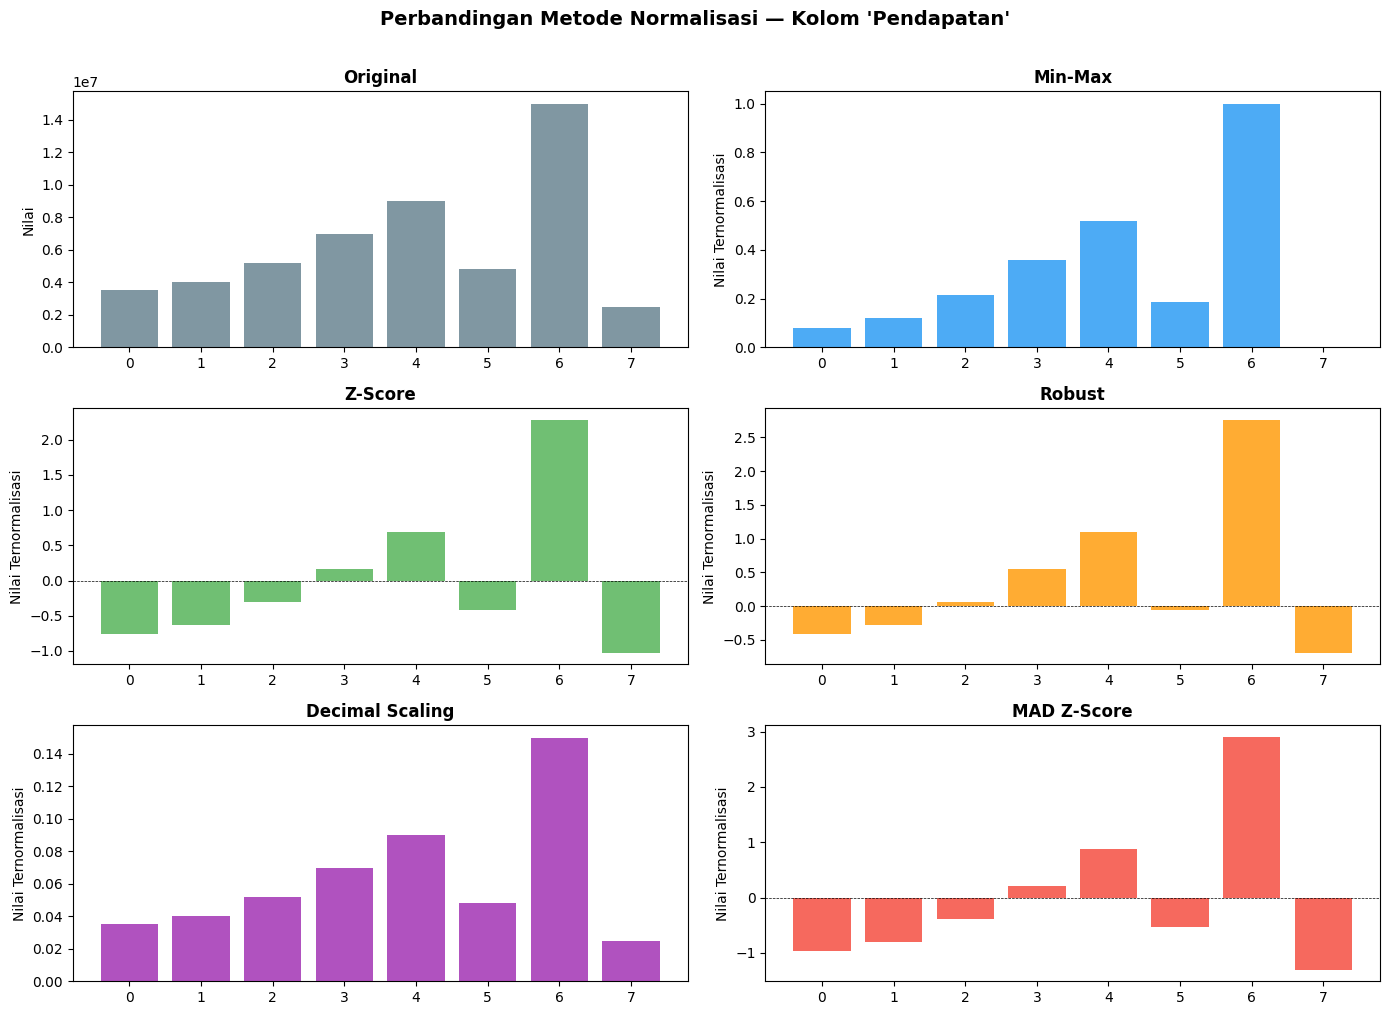

Visualisasi berhasil disimpan!


In [36]:
# ─────────────────────────────────────────────────────────────
#  Visualisasi perbandingan (opsional, jika matplotlib tersedia)
# ─────────────────────────────────────────────────────────────

try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    methods = ['Min-Max', 'Z-Score', 'Robust', 'Decimal Scaling', 'MAD Z-Score']
    colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
    idx     = range(len(df_norm))

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle(f"Perbandingan Metode Normalisasi — Kolom '{col_focus}'",
                 fontsize=14, fontweight='bold', y=1.01)

    # Plot original
    axes[0,0].bar(idx, df_norm[col_focus], color='#607D8B', alpha=0.8)
    axes[0,0].set_title('Original', fontweight='bold')
    axes[0,0].set_ylabel('Nilai')

    for ax, method, color in zip(axes.flatten()[1:], methods, colors):
        ax.bar(idx, results[method], color=color, alpha=0.8)
        ax.set_title(method, fontweight='bold')
        ax.set_ylabel('Nilai Ternormalisasi')
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

    plt.tight_layout()
    plt.savefig('D:/kuliah/...normalisasi_perbandingan.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Visualisasi berhasil disimpan!")
except ImportError:
    print("matplotlib tidak tersedia, skip visualisasi.")

## 4.8 Contoh Penggunaan dalam Pipeline sklearn

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load dataset Iris
iris    = load_iris()
X, y    = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Pipeline: Normalisasi + KNN
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5))
])

pipeline.fit(X_train, y_train)
akurasi = pipeline.score(X_test, y_test)

print("=" * 50)
print(" PIPELINE: MinMaxScaler + KNN (Iris Dataset)")
print("=" * 50)
print(f"  Akurasi dengan Min-Max + KNN : {akurasi*100:.2f}%")

# Bandingkan tanpa normalisasi
from sklearn.neighbors import KNeighborsClassifier as KNC
knn_no_scale = KNC(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
akurasi_raw = knn_no_scale.score(X_test, y_test)
print(f"  Akurasi tanpa normalisasi    : {akurasi_raw*100:.2f}%")
print(f"\n  → Normalisasi {'meningkatkan' if akurasi >= akurasi_raw else 'tidak mengubah'} akurasi!")

 PIPELINE: MinMaxScaler + KNN (Iris Dataset)
  Akurasi dengan Min-Max + KNN : 100.00%
  Akurasi tanpa normalisasi    : 100.00%

  → Normalisasi meningkatkan akurasi!


---
##  Kesimpulan

### Missing Values Imputation (WKNN)
- WKNN mengisi nilai hilang menggunakan **rata-rata tertimbang** dari K tetangga terdekat
- Bobot dihitung sebagai $s_i = 1 / \text{jarak}^2$ — tetangga yang lebih dekat mendapat bobot lebih besar
- Untuk data klasifikasi, dapat menggunakan **same-class weighting** agar estimasi lebih akurat
- Nilai K dipilih secara empiris (tidak ada rumus baku)

### Normalisasi Data
| Situasi | Rekomendasi Metode |
|---------|--------------------|
| Data tanpa outlier, butuh rentang [0,1] | **Min-Max** |
| Data distribusi normal, SVM, PCA | **Z-Score** |
| Data dengan banyak outlier | **Robust Scaler** |
| Data teks / sparse, cosine similarity | **L2 Normalizer** |
| Standarisasi lebih robust dari Z-Score | **MAD Z-Score** |